##  Monte Carlo Simulation — ONGC Price Prediction (Next 252 Trading Days)

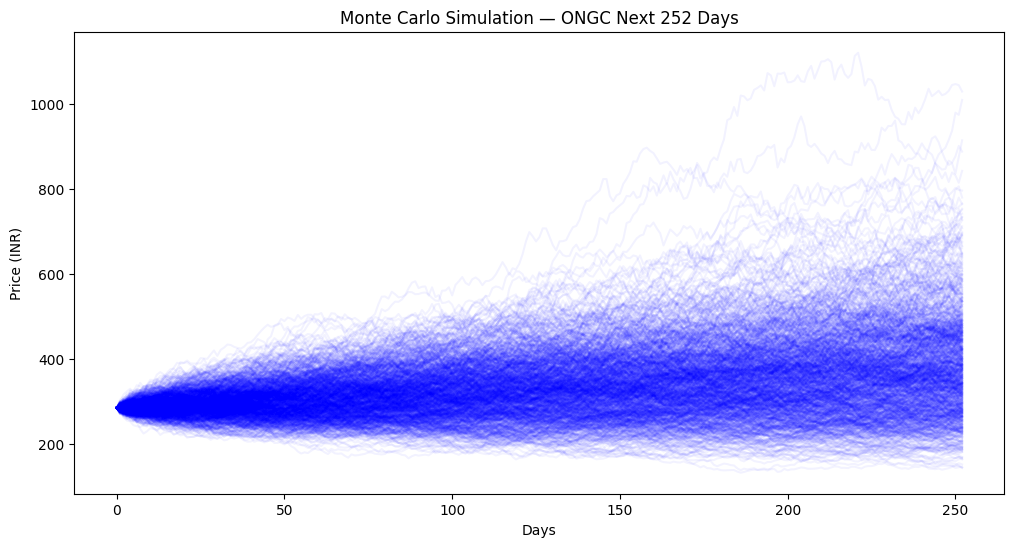

Current Price:   ₹284.65
Best Case:       ₹1029.35
Worst Case:      ₹143.26
Average Case:    ₹382.90
Median Case:     ₹368.77


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

data = yf.download('ONGC.NS', start='2024-01-01', end='2026-04-01', progress=False)['Close']
data = data.squeeze()

returns = data.pct_change().dropna()
avg_return = returns.mean()
std = returns.std()
current_price = data.iloc[-1]

simulations = 1000
days = 252

results = []

for i in range(simulations):
    prices = [current_price]
    for d in range(days):
        price = prices[-1] * np.exp(avg_return + std * np.random.normal())
        prices.append(price)
    results.append(prices)

plt.figure(figsize=(12, 6))
for i in range(simulations):
    plt.plot(results[i], alpha=0.05, color='blue')

plt.title('Monte Carlo Simulation — ONGC Next 252 Days')
plt.xlabel('Days')
plt.ylabel('Price (INR)')
plt.show()

results_array = np.array(results)
final_prices = results_array[:, -1]

print(f"Current Price:   ₹{float(current_price):.2f}")
print(f"Best Case:       ₹{final_prices.max():.2f}")
print(f"Worst Case:      ₹{final_prices.min():.2f}")
print(f"Average Case:    ₹{final_prices.mean():.2f}")
print(f"Median Case:     ₹{np.median(final_prices):.2f}")

Okay this one was by far the most fun program I built in this 
whole project. Monte Carlo Simulation basically asks — if we 
took everything we know about how ONGC has moved in the past 
and simulated 1000 possible futures, what would they look like?

And the chart that came out honestly blew my mind a little. 
All 1000 paths start from today's price of INR 284.65 and 
spread out like a giant fan over the next 252 trading days. 
The wider the fan gets, the more uncertain the future becomes. 
Which makes total sense — nobody knows exactly where a stock 
will be in a year.

---

### What the numbers say:

| Scenario | Price |
|----------|-------|
| Current Price | INR 284.65 |
| Best Case | INR 1029.35 |
| Worst Case | INR 143.26 |
| Average Case | INR 382.90 |
| Median Case | INR 368.77 |

---

### Breaking it down:

**Average case of INR 382.90** is actually really interesting. 
That's a 34% upside from where ONGC is sitting right now. 
Given that crude oil is still elevated due to the Iran-USA 
tensions and ONGC directly benefits from high crude prices, 
this feels like a realistic optimistic scenario if things 
stay the way they are.

**Median of INR 368.77** is probably the more honest number 
to look at. This means exactly 500 out of 1000 simulations 
ended above this price and 500 ended below. So there's 
basically a coin flip chance of ONGC being above INR 368 
in a year from now.

**Worst case of INR 143.26** is scary but important to know. 
A 50% crash from current levels would probably only happen 
if the Iran-USA conflict suddenly resolved, crude crashed 
back to $50, and the broader Indian market also sold off 
heavily at the same time. Unlikely but not impossible — 
and that's exactly why we simulate.

**Best case of INR 1029.35** is nearly 4x from current price. 
This would need crude to hit $150+ and sustained geopolitical 
premium on oil stocks. Extremely unlikely in 252 days but 
mathematically possible which is why it shows up in 1000 
simulations.

---

### What I learnt from this 

The most important thing Monte Carlo taught me is that 
stock price prediction is never one number — it's always 
a range of possibilities. Anyone who tells you a stock 
WILL be at a specific price in a year is lying.

What we CAN say with confidence is:
- Most likely ONGC ends somewhere between INR 300 and INR 500
- There's significant downside risk if geopolitical tensions ease
- The upside is much larger than the downside in absolute terms

This is exactly how hedge funds and quant traders think 
about positions — not "will this stock go up" but 
"what is the probability distribution of outcomes 
and is the risk worth taking."

For a stock directly tied to one of the biggest 
geopolitical events of 2025-2026, ONGC's simulation 
results actually look pretty decent. The average and 
median both show meaningful upside which aligns with 
the high crude oil environment we are currently in.